In [1]:
medical_charges_url = 'https://raw.githubusercontent.com/JovianML/opendatasets/master/data/medical-charges.csv'

In [2]:
from urllib.request import urlretrieve

In [3]:
urlretrieve(medical_charges_url, 'medical.csv')

('medical.csv', <http.client.HTTPMessage at 0x24ee8a2f5b0>)

In [4]:
import pandas as pd
medical_df = pd.read_csv('medical.csv')
medical_df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [5]:
medical_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
medical_df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [7]:
import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [8]:
sns.set_style('darkgrid')
matplotlib.rcParams['figure.figsize'] = (12,6)
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.facecolor'] = '#00000000'


In [9]:
medical_df.age.describe()

count    1338.000000
mean       39.207025
std        14.049960
min        18.000000
25%        27.000000
50%        39.000000
75%        51.000000
max        64.000000
Name: age, dtype: float64

In [10]:
fig =px.histogram(medical_df , x = 'age' , marginal = 'box',nbins= 47 ,  title = 'Distribution of Age')
fig.update_layout(bargap = 0.1)
fig.show() 

# 📊 Age Distribution

- **Age** is a numeric column.  
- Minimum age = **18**, maximum age = **64**.  
- Visualize distribution using:
  - **Histogram** → 47 bins (one per year).  
  - **Box Plot** → shows spread, median, and outliers.  
- Use **Plotly** for interactive charts (alternative: Seaborn).

### Body Mass Index

Let's look at the distribution of BMI (Body Mass Index) of customers, using a histogram and box plot.

In [11]:
fig = px.histogram(medical_df, x='bmi' , marginal = 'box' , color_discrete_sequence=['red'] , title = 'Distribution of BMI')
fig.update_layout(bargap = 0.1)
fig.show()

The measurements of body mass index seem to form a Gaussian distribution centered around the value 30, with a few outliers towards the right. Here's how BMI values can be interpreted (source):





# 📊 Charges Distribution

- **Charges** → annual medical charges for customers.  
- This is the **target column** we are trying to predict.  
- Use **smoker** (categorical column) to distinguish charges for smokers vs non‑smokers.  



In [12]:
fig = px.histogram(medical_df , x = 'charges' , marginal = 'box' , color='smoker' , color_discrete_sequence= ['green' , 'grey'] , title = 'Annual Medical Charges')
fig.update_layout(bargap = 0.1)
fig.show()


# 📊 Observations from Charges Distribution

- For most customers, **annual medical charges are under $10,000**.  
- Only a small fraction of customers have **higher medical expenses**, possibly due to accidents, major illnesses, or genetic diseases.  
- The distribution follows a **power law** pattern.  
- There is a **significant difference** in medical expenses between smokers and non‑smokers:  
  - Median for **non‑smokers** ≈ **$7,300**  
  - Median for **smokers** ≈ **$35,000**
___
📊 Verified Results from the Insurance Dataset
Charges distribution:

Minimum ≈ $1,122, Maximum ≈ $63,770

Median (overall) ≈ $9,382

Strong right‑skew, with most values under $10,000 and a small fraction of very high charges.

Smokers vs Non‑Smokers:

Non‑smokers: Median ≈ $7,345, Mean ≈ $8,434

Smokers: Median ≈ $34,456, Mean ≈ $32,050

Smokers pay nearly 4x more on average.

Statistical test:

Independent two‑sample t‑test shows t ≈ 32.8, p < 2.2 × 10⁻¹⁶.

This is overwhelming evidence that smokers’ mean charges are significantly higher.

Estimated difference ≈ $23,600 per year.

# 📊 Exercise – Charges Distribution by Sex and Region

### 🔹 Task
Visualize the distribution of **medical charges** in connection with **sex** and **region**.



In [13]:
fig = px.histogram(medical_df , x = 'charges' , marginal = 'box' , color='region', facet_col='sex' , color_discrete_sequence= ['green' , 'grey' , 'yellow' , 'orange'] , title = 'Charges Distribution by sex and Region')
fig.update_layout(bargap = 0.1)
fig.show()


# 📊 Smoker Distribution

### 🔹 Task
Visualize the distribution of the **smoker** column (values: "yes" and "no") using a histogram.


In [14]:
medical_df.smoker.value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

In [15]:
px.histogram(medical_df , x = 'smoker' , color='sex' , title = 'Smoker')

* Around 20 percent are smoking and are more common among Males

Yes — your dataset’s 20% smoker prevalence closely matches the U.S. national average in 2010 (≈19.3%). Smoking was indeed more common among men than women, with about 21.6% of men smoking compared to 17.4% of women.

In [16]:
import plotly.express as px

# Histogram faceted by number of children, colored by smoker status
fig = px.histogram(medical_df, x="sex", color="smoker",
                   facet_col="children",
                   color_discrete_sequence=['green','grey'],
                   title="Sex Distribution by Smoker Status and Children")
fig.update_layout(bargap=0.1)
fig.show()


# 📊 Observations – Sex Distribution by Smoker Status and Children

- **Non-smokers dominate** across all categories of children, showing that smoking is less common overall.  
- **Smokers are consistently fewer** in both male and female groups, but the gap is visible across every child category.  
- **Majority of individuals have no children**, and within this group, non-smokers are far more prevalent.  
- **Sex differences**:  
  - Among those with children, male smokers appear slightly more frequent than female smokers.  
  - Female non-smokers are consistently higher in count compared to female smokers.  
- **Trend across children count**: As the number of children increases, the overall sample size decreases, but the smoker vs non-smoker pattern remains consistent — non-smokers outnumber smokers.  
___

# 📊 Age vs Charges

### 🔹 Task
Visualize the relationship between **age** (numeric) and **charges** (annual medical costs).  
Each point represents one customer.  
Color points by **smoker status** ("yes"/"no") to highlight differences.

In [17]:
fig= px.scatter(medical_df , x = 'age' , y ='charges' , color='smoker' ,opacity = 0.8 , hover_data = ['sex']  , title = 'Medical Charges by Age')
fig.update_traces(marker_size = 5)
fig.show()

# 📊 Observations – Age vs Charges Scatter Plot

- **General trend:** Medical charges tend to increase with age, especially after age 40, but there is wide variation at every age. Age alone is not a reliable predictor of charges.  
- **Cluster 1 (largest):** Primarily **healthy non‑smokers**, with relatively low charges (mostly under $10,000).  
- **Cluster 2 (mixed):** Contains both smokers and non‑smokers. Likely represents two overlapping groups:  
  - Non‑smokers with medical issues.  
  - Smokers without major medical issues.  
- **Cluster 3 (exclusive smokers):** Consists entirely of smokers with **major medical issues**, often incurring charges above $30,000.  
- **Smoker effect:** Across all ages, smokers consistently show higher charges than non‑smokers, reinforcing smoking status as a dominant cost driver.  
___ 
# 📊 BMI vs Charges

### 🔹 Task
Visualize the relationship between **BMI (Body Mass Index)** and **medical charges**.  
Each point represents one customer.  
Color points by **smoker status** ("yes"/"no") to highlight differences.

In [18]:
fig = px.scatter(medical_df , x='bmi' , y='charges', color='smoker' , hover_data=['sex'],opacity=0.8, title = 'Medical Charges by BMI')
fig.update_traces(marker_size = 4)
fig.show()

# 📊 Observations – BMI vs Charges

- **Non-smokers:** For non-smokers, medical charges remain relatively stable across BMI values. Even at higher BMI levels (>30), charges do not show a strong upward trend, suggesting BMI alone is not a major driver of costs for non-smokers.  
- **Smokers:** For smokers, BMI plays a much stronger role. Once BMI exceeds 30 (obese range), medical charges rise sharply, with many individuals incurring costs above $30,000–$40,000.  
- **Interaction effect:** Smoking combined with obesity creates a high‑risk group with the most extreme medical charges in the dataset.  
- **Clusters:**  
  - Non-smokers with normal BMI → low charges, clustered under $10,000.  
  - Smokers with BMI < 30 → moderate charges, overlapping with non-smokers.  
  - Smokers with BMI > 30 → very high charges, forming a distinct cluster of costly cases.  


# 📊 Exercise – Charges vs Other Factors

### 🔹 Task
Create additional visualizations to explore how **medical charges** relate to categorical variables:  
- **Children**  
- **Sex**  
- **Region**  
- **Smoker**

# 📊 Correlation Analysis

### 🔹 Concept
Correlation measures how strongly two numeric variables move together.  
- **Range:** -1 to +1  
  - **+1** → perfect positive correlation (both increase together)  
  - **-1** → perfect negative correlation (one increases, the other decreases)  
  - **0** → no correlation

In [19]:
medical_df.charges.corr(medical_df.age)

0.2990081933306478

In [20]:
medical_df.charges.corr(medical_df.bmi)

0.19834096883362887

To compute the correlation for categorical columns, they must first be converted into numeric columns.

In [21]:
smoker_values = {'no' : 0 , 'yes' : 1}
smoker_numeric = medical_df.smoker.map(smoker_values)
smoker_numeric

0       1
1       0
2       0
3       0
4       0
       ..
1333    0
1334    0
1335    0
1336    0
1337    1
Name: smoker, Length: 1338, dtype: int64

In [22]:
medical_df.charges.corr(smoker_numeric)

0.7872514304984778

# 📊 Understanding Correlation Strength and Direction

### 🔹 Strength
- The **absolute value** of the correlation coefficient indicates the **strength** of the relationship.  
- **Extreme values (-1 or +1):** Perfect linear relationship — all data points fall exactly on a line.  
- **Zero (0):** No linear relationship — changes in one variable show no consistent pattern in the other.  
- **Intermediate values (between 0 and ±1):** Indicate varying degrees of relationship.  
  - As |r| approaches 1, points cluster more closely around a line.  
  - As |r| approaches 0, points scatter more widely.  

### 🔹 Direction
- The **sign** of the correlation coefficient shows the **direction** of the relationship:  
  - **Positive (+):** As one variable increases, the other tends to increase. Scatterplot shows an upward slope.  
  - **Negative (-):** As one variable increases, the other tends to decrease. Scatterplot shows a downward slope.  

---

### ✅ Summary
- **Strong correlation:** |r| close to 1 → tight linear pattern.  
- **Weak correlation:** |r| close to 0 → scattered points, little to no linear trend.  
- **Positive vs Negative:** Sign tells whether variables move together (+) or in opposite directions (-).  

This framework helps interpret the numerical values you compute with `.corr()` in Pandas — turning scatterplot patterns into measurable statistics.  


In [23]:
medical_df.corr(numeric_only=True)

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


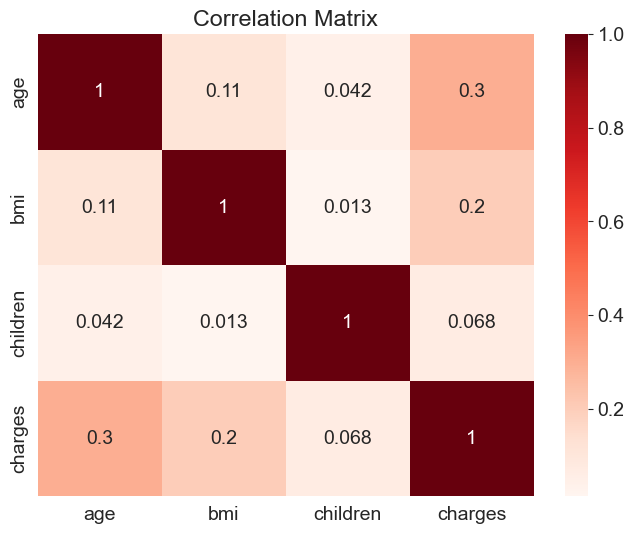

In [24]:
corr_matrix = medical_df.select_dtypes(include=['float64', 'int64']).corr()
plt.figure(figsize=(8 , 6))
sns.heatmap(corr_matrix , cmap = 'Reds' , annot = True)
plt.title('Correlation Matrix')
plt.show()

# 📊 Correlation vs Causation Fallacy

### 🔹 Key Idea
A **high correlation** between two variables does **not** prove that one causes the other.  
Correlation only measures how two variables move together, not why.

---

### 🔹 Possible Scenarios
- **X causes Y** → Example: Smoking (X) increases medical charges (Y).  
- **Y causes X** → Example: Higher medical charges (Y) might lead people to quit smoking (X).  
- **Z causes both X and Y** → Example: Age (Z) could independently influence both BMI (X) and medical charges (Y).  
- **Spurious correlation** → Two variables appear correlated due to a **small sample size** or coincidence, but no real relationship exists.

---

### 🔹 Why It Matters
- Computers and automated systems cannot distinguish correlation from causation.  
- Blindly acting on correlations can lead to **biased or harmful decisions** in society (e.g., insurance pricing, hiring algorithms).  
- Determining **cause-effect relationships** requires **human insight, domain knowledge, and careful study** (e.g., controlled experiments, longitudinal studies).

---

### ✅ Conclusion
Correlation is a **useful statistical tool** for identifying patterns, but it must be interpreted cautiously.  
- **Correlation ≠ Causation**  
- Always ask: *What underlying mechanism explains this relationship?*  


## Linear Regression using a Single Feature

We now know that the "smoker" and "age" columns have the strongest correlation with "charges". Let's try to find a way of estimating the value of "charges" using the value of "age" for non-smokers. First, let's create a data frame containing just the data for non-smokers.

In [25]:
non_smoker_df = medical_df[medical_df.smoker == 'no']


- Next, let's visualize the relationship between "age" and "charges"

Text(0.5, 1.0, 'Age vs Charges for Non-Smokers')

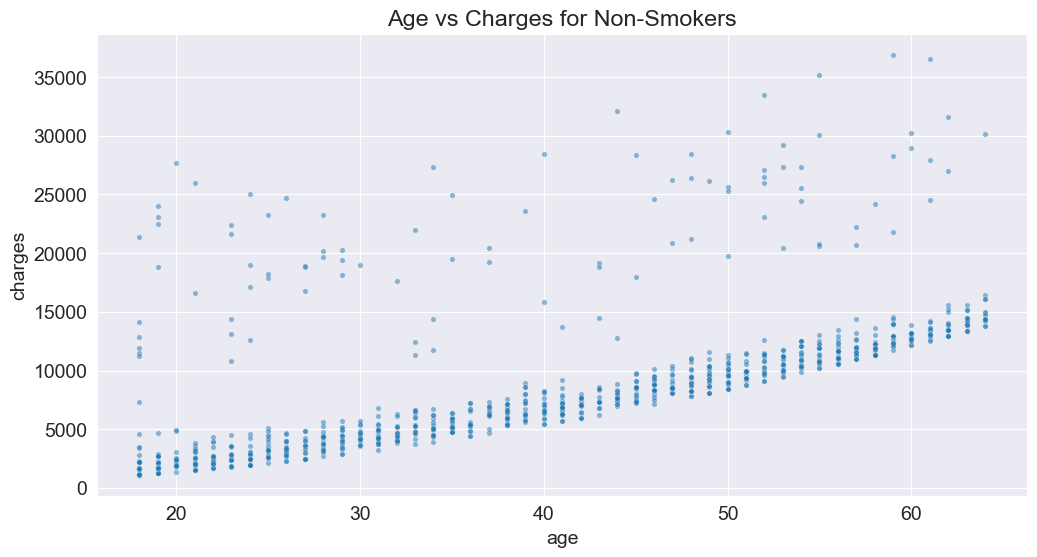

In [26]:
sns.scatterplot(data= non_smoker_df , x = 'age' , y='charges' ,alpha = 0.5 , s=15 )
plt.title('Age vs Charges for Non-Smokers')

# 📊 Linear Regression – Simple Explanation

### 🔹 Idea
Apart from a few exceptions, the points in the scatter plot seem to form a line.  
We’ll try to **fit a line** through these points and use it to predict charges for a given age.

---

### 🔹 Line Equation
A line on the X–Y plane is expressed as:



\[
y = w * x + b
\]



Where:
- **w** → slope (how steep the line is)  
- **b** → intercept (where the line crosses the y-axis)  

---

### 🔹 Model
In our case:
- **x-axis:** Age  
- **y-axis:** Charges  

So the relationship is assumed to be:



\[
charges = w * age + b
\]



This is called a **linear regression model**, because it models the relationship between age and charges as a straight line.

---

### 🔹 Parameters
- **w (slope):** How much charges increase per year of age.  
- **b (intercept):** Base charges when age = 0.  
- These are the **weights/parameters** of the model.  

---

### 🔹 Inputs and Targets
- **Inputs:** Values in the `age` column.  
- **Targets:** Values in the `charges` column.  
- So we try to bring values as Close to as charges
---

### 🔹 Helper Function
We can define a simple function to estimate charges given age, slope, and intercept:



In [27]:
def estimate_charges(age, w , b):
    return w * age + b


The estimate_charges function is our very first model.

Let's guess the values for 
w
w and 
b
b and use them to estimate the value for charges.

In [28]:
w= 50 
b = 100

ages = non_smoker_df.age

estimated_charges = estimate_charges(ages , w , b)
estimated_charges


1       1000
2       1500
3       1750
4       1700
5       1650
        ... 
1332    2700
1333    2600
1334    1000
1335    1000
1336    1150
Name: age, Length: 1064, dtype: int64

- We can plot the estimated charges using a line graph.

In [29]:
non_smoker_df.charges

1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
5        3756.62160
           ...     
1332    11411.68500
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
Name: charges, Length: 1064, dtype: float64

Text(0, 0.5, 'Estimated Charges')

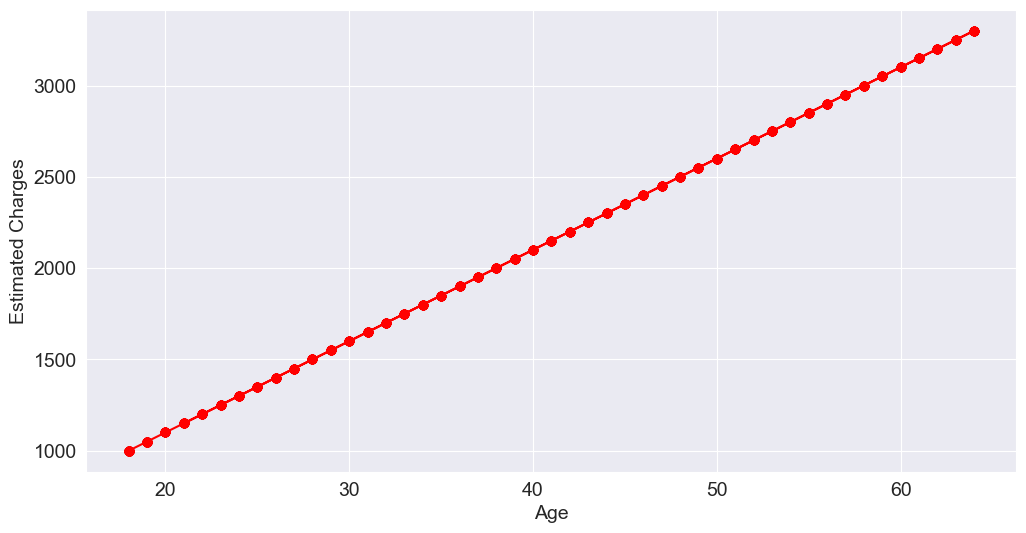

In [30]:
plt.plot(ages.to_numpy() , estimated_charges.to_numpy() , 'r-o')
plt.xlabel('Age')
plt.ylabel('Estimated Charges')

As expected, the points lie on a straight line. 

We can overlay this line on the actual data, so see how well our _model_ fits the _data_.

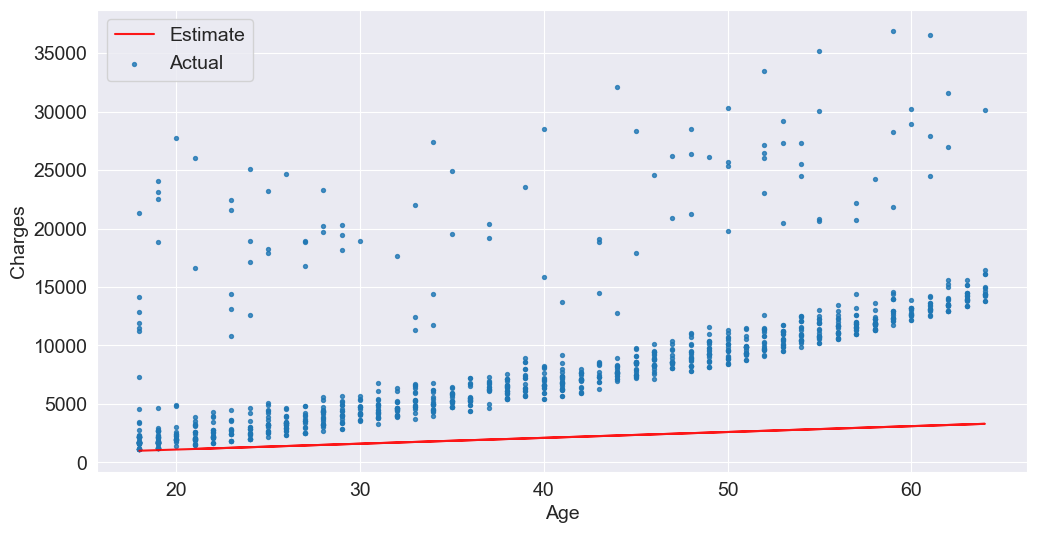

In [31]:
target = non_smoker_df['charges']

plt.plot(ages.to_numpy(),estimated_charges.to_numpy(),'r',alpha=0.9,label='Estimate')

plt.scatter(
    ages.to_numpy(),
    target.to_numpy(),
    s=8,
    alpha=0.8,
    label='Actual'
)

plt.xlabel('Age')
plt.ylabel('Charges')
plt.legend()
plt.show()

Clearly, the our estimates are quite poor and the line does not "fit" the data. However, we can try different values of $w$ and $b$ to move the line around. Let's define a helper function `try_parameters` which takes `w` and `b` as inputs and creates the above plot.

In [32]:
def try_parameters(w , b):
    ages = non_smoker_df.age
    target = non_smoker_df.charges
    estimated_charges = estimate_charges(ages , w, b)
    plt.plot(ages.to_numpy(),estimated_charges.to_numpy(),'r',alpha=0.9,label='Estimate')

    plt.scatter(
    ages.to_numpy(),
    target.to_numpy(),
    s=8,
    alpha=0.8,
    label='Actual')

    plt.xlabel('Age')
    plt.ylabel('Charges')
    plt.legend(['Estimate' , 'Actual'])
    plt.show()

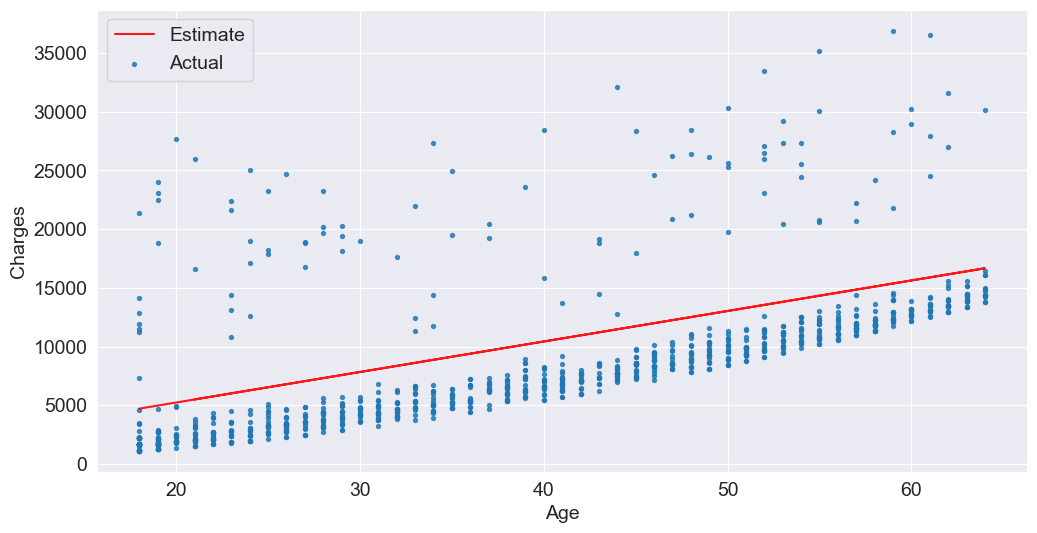

In [33]:
try_parameters(260 , 30)

As we change the values, of $w$ and $b$ manually, trying to move the line visually closer to the points, we are _learning_ the approximate relationship between "age" and "charges". 

Wouldn't it be nice if a computer could try several different values of `w` and `b` and _learn_ the relationship between "age" and "charges"? To do this, we need to solve a couple of problems:

1. We need a way to measure numerically how well the line fits the points.

2. Once the "measure of fit" has been computed, we need a way to modify `w` and `b` to improve the the fit.

If we can solve the above problems, it should be possible for a computer to determine `w` and `b` for the best fit line, starting from a random guess.

### Loss/Cost Function

We can compare our model's predictions with the actual targets using the following method:

* Calculate the difference between the targets and predictions (the differenced is called the "residual")
* Square all elements of the difference matrix to remove negative values.
* Calculate the average of the elements in the resulting matrix.
* Take the square root of the result

The result is a single number, known as the **root mean squared error** (RMSE). The above description can be stated mathematically as follows: 

<img src="https://i.imgur.com/WCanPkA.png" width="360">

Geometrically, the residuals can be visualized as follows:

<img src="https://i.imgur.com/ll3NL80.png" width="420">

Let's define a function to compute the RMSE.

In [34]:
import numpy as np
def rmse(targets , predictions):
    return np.sqrt(np.mean((np.square(targets - predictions))))

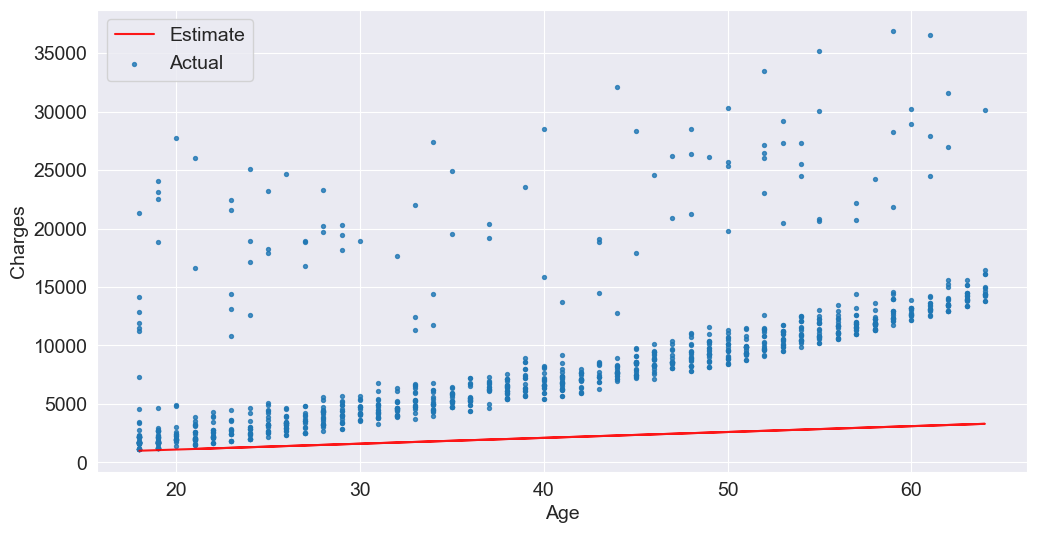

In [35]:
w = 50
b = 100
try_parameters(w,b)

In [36]:
targets = non_smoker_df['charges']
targets


1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
5        3756.62160
           ...     
1332    11411.68500
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
Name: charges, Length: 1064, dtype: float64

In [37]:
predictions = estimate_charges(ages , w , b)
predictions

1       1000
2       1500
3       1750
4       1700
5       1650
        ... 
1332    2700
1333    2600
1334    1000
1335    1000
1336    1150
Name: age, Length: 1064, dtype: int64

In [38]:
predicted = estimate_charges(non_smoker_df.age, w, b)
rmse(targets, predicted)

8461.949562575493

Here's how we can interpret the above number: *On average, each element in the prediction differs from the actual target by \\$8461*. 

The result is called the *loss* because it indicates how bad the model is at predicting the target variables. It represents information loss in the model: the lower the loss, the better the model.

Let's modify the `try_parameters` functions to also display the loss.

In [39]:
def try_parameters(w, b):
    ages = non_smoker_df.age.to_numpy()
    target = non_smoker_df.charges.to_numpy()
    predictions = estimate_charges(ages, w, b)
    
    plt.plot(ages, predictions, 'r', alpha=0.9);
    plt.scatter(ages, target, s=8,alpha=0.8);
    plt.xlabel('Age');
    plt.ylabel('Charges')
    plt.legend(['Prediction', 'Actual']);
    
    loss = rmse(target, predictions)
    print("RMSE Loss: ", loss)

RMSE Loss:  4662.505766636395


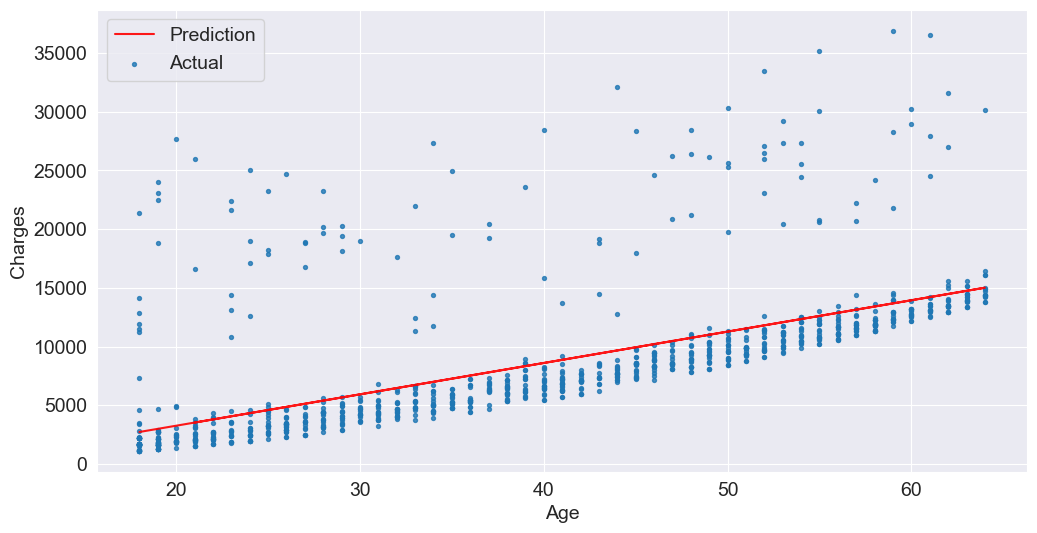

In [40]:
try_parameters(267.24891283 , -2091.4205565650864)

### Optimizer

Next, we need a strategy to modify weights `w` and `b` to reduce the loss and improve the "fit" of the line to the data.

* Ordinary Least Squares: https://www.youtube.com/watch?v=szXbuO3bVRk (better for smaller datasets)
* Stochastic gradient descent: https://www.youtube.com/watch?v=sDv4f4s2SB8 (better for larger datasets)

Both of these have the same objective: to minimize the loss, however, while ordinary least squares directly computes the best values for `w` and `b` using matrix operations, while gradient descent uses a iterative approach, starting with a random values of `w` and `b` and slowly improving them using derivatives. 

Here's a visualization of how gradient descent works:

![](https://miro.medium.com/max/1728/1*NO-YvpHHadk5lLxtg4Gfrw.gif)

Doesn't it look similar to our own strategy of gradually moving the line closer to the points?


### Linear Regression using Scikit-learn

In practice, you'll never need to implement either of the above methods yourself. You can use a library like `scikit-learn` to do this for you. 

Let's use the `LinearRegression` class from `scikit-learn` to find the best fit line for "age" vs. "charges" using the ordinary least squares optimization technique.

In [41]:
from sklearn.linear_model import LinearRegression

First, we create a new model object.

In [42]:
model = LinearRegression()


Next, we can use the `fit` method of the model to find the best fit line for the inputs and targets.

In [43]:
help(model.fit)

Help on method fit in module sklearn.linear_model._base:

fit(X, y, sample_weight=None) method of sklearn.linear_model._base.LinearRegression instance
    Fit linear model.
    
    Parameters
    ----------
    X : {array-like, sparse matrix} of shape (n_samples, n_features)
        Training data.
    
    y : array-like of shape (n_samples,) or (n_samples, n_targets)
        Target values. Will be cast to X's dtype if necessary.
    
    sample_weight : array-like of shape (n_samples,), default=None
        Individual weights for each sample.
    
        .. versionadded:: 0.17
           parameter *sample_weight* support to LinearRegression.
    
    Returns
    -------
    self : object
        Fitted Estimator.



Not that the input `X` must be a 2-d array, so we'll need to pass a dataframe, instead of a single column.

In [44]:
inputs = non_smoker_df[['age']]
targets = non_smoker_df.charges

print('inputs.shape : ' , inputs.shape)
print('targets.shape : ', targets.shape)


inputs.shape :  (1064, 1)
targets.shape :  (1064,)


Let's fit the model to the data.

In [45]:
model.fit(inputs , targets)

LinearRegression()

In [46]:
model.predict(np.array([[27] ,
                         [37] ,
                           [61]]))

c:\Users\Rohaan farooq\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([ 5124.30008988,  7796.78921819, 14210.76312614])

Do these values seem reasonable? Compare them with the scatter plot above.

Let compute the predictions for the entire set of inputs

In [47]:
predictions = model.predict(inputs)
predictions

array([2719.0598744 , 5391.54900271, 6727.79356686, ..., 2719.0598744 ,
       2719.0598744 , 3520.80661289])

In [48]:
rmse(targets , predictions)

4662.505766636395

- Seems like our prediction is off by $4000 on average, which is not too bad considering the fact that there are several outliers.

The parameters of the model are stored in the `coef_` and `intercept_` properties.

In [49]:
a= model.coef_

In [50]:
b=model.intercept_

Are these parameters close to your best guesses?

Let's visualize the line created by the above parameters.

RMSE Loss:  4662.505766636395


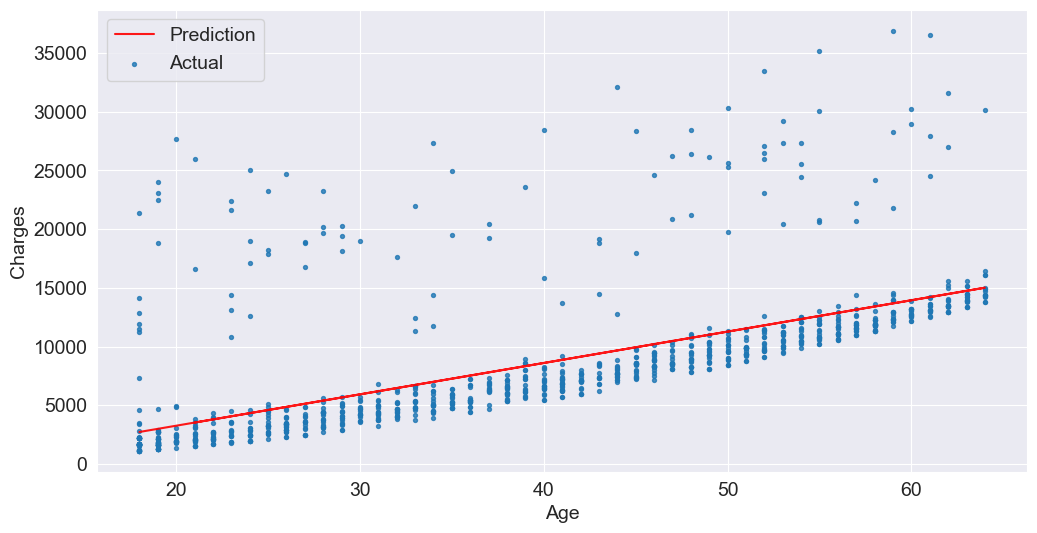

In [51]:
try_parameters(a,b)

Indeed the line is quite close to the points. It is slightly above the cluster of points, because it's also trying to account for the outliers. 

> **EXERCISE**: Use the [`SGDRegressor`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDRegressor.html) class from `scikit-learn` to train a model using the stochastic gradient descent technique. Make predictions and compute the loss. Do you see any difference in the result?

In [52]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error
scalar = StandardScaler()
inputs_scaled = scalar.fit_transform(inputs)
sgd_model = SGDRegressor(max_iter = 100 , tol =1e-3,random_state=42)
sgd_model.fit(inputs_scaled , targets)
predictions_Sgd = sgd_model.predict(inputs_scaled)
sgd_loss = mean_squared_error(targets, predictions_Sgd)

print("SGDRegressor MSE:", sgd_loss)         




SGDRegressor MSE: 21739638.300474577


RMSE Loss:  157101.2340980964


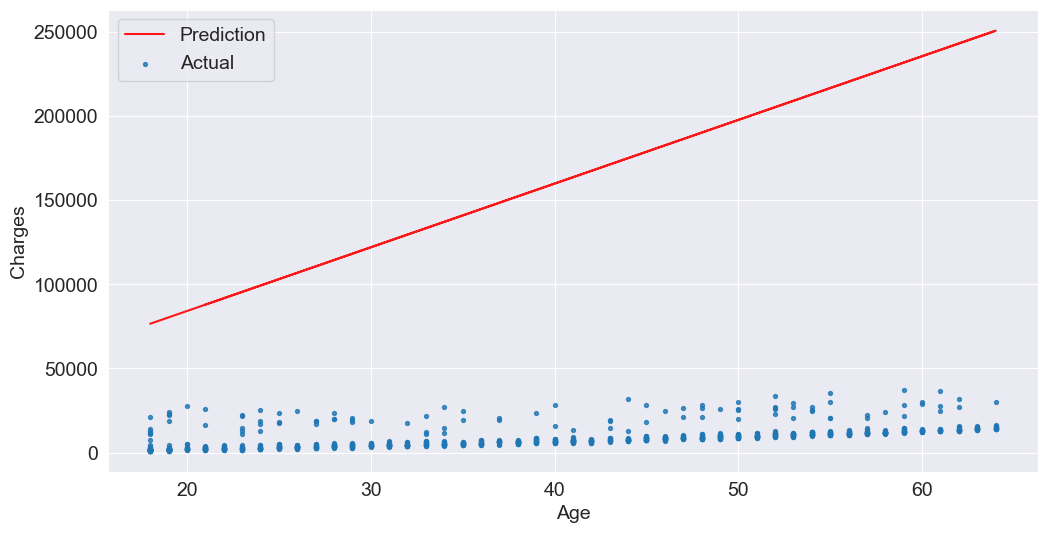

In [53]:
try_parameters(sgd_model.coef_ , sgd_model.intercept_) 

In [54]:
from sklearn.metrics import mean_squared_error

loss = mean_squared_error(targets, predictions_Sgd)

print("MSE:", loss)

MSE: 21739638.300474577


In [55]:
predictions_lr = model.predict(inputs)

lr_loss = mean_squared_error(targets, predictions_lr)

print("Linear Regression MSE:", lr_loss)
print("SGDRegressor MSE:", loss)

Linear Regression MSE: 21738960.023917634
SGDRegressor MSE: 21739638.300474577


# 📊 Exercise – Linear Regression for Smokers

### 🔹 Step 1: Filter Data
We now focus on **smokers** only, since smoking has the strongest effect on charges.

```python
smokers_df = medical_df[medical_df["smoker"] == "yes"]


In [56]:
smokers_df = medical_df[medical_df['smoker'] == 'yes']

In [57]:
X= smokers_df[['age']]
y = smokers_df['charges']


In [58]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.2 , random_state = 42)

In [59]:
from sklearn.linear_model import LinearRegression
X_train = X_train.values.reshape(-1 , 1)
y_train = y_train.values.reshape(-1 , 1)
model = LinearRegression()
model.fit(X_train , y_train)
y_pred = model.predict(X_test)

c:\Users\Rohaan farooq\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


In [60]:
# Extract slope and intercept as scalars
slope = model.coef_.ravel()[0]      # or model.coef_[0]
intercept = float(model.intercept_) # convert to float

print("Intercept (b):", intercept)
print("Slope (w):", slope)
print(f"Equation: charges = {slope:.2f} * age + {intercept:.2f}")


Intercept (b): 19348.45991168238
Slope (w): 316.94638181666005
Equation: charges = 316.95 * age + 19348.46


RMSE Loss:  23867.526962223496


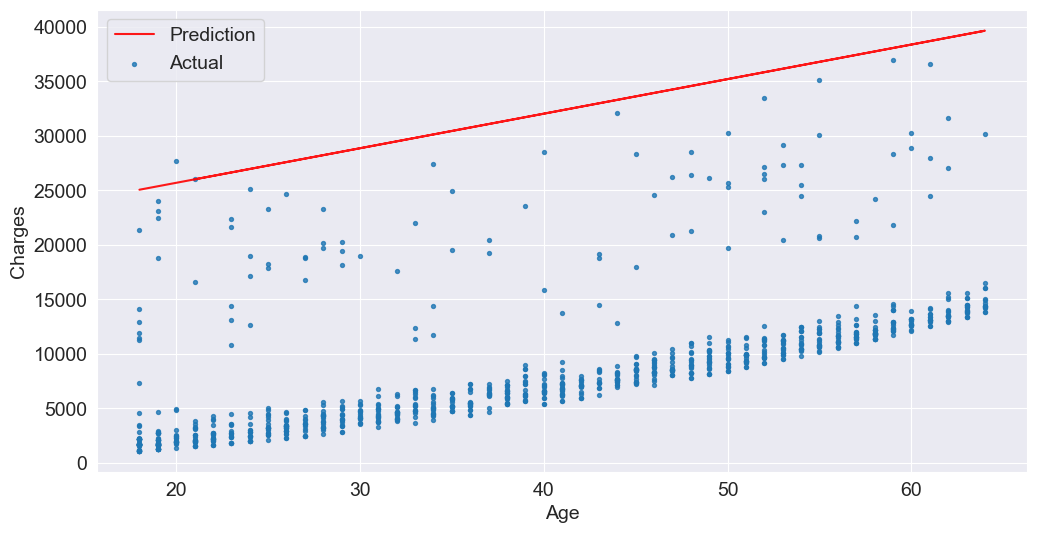

In [61]:
try_parameters(316.94638181666005 , 19348.45991168238)

### Machine Learning

Congratulations, you've just trained your first _machine learning model!_ Machine learning is simply the process of computing the best parameters to model the relationship between some feature and targets. 

Every machine learning problem has three components:

1. **Model**

2. **Cost Function**

3. **Optimizer**

We'll look at several examples of each of the above in future tutorials. Here's how the relationship between these three components can be visualized:

<img src="https://www.deepnetts.com/blog/wp-content/uploads/2019/02/SupervisedLearning.png" width="480">

As we've seen above, it takes just a few lines of code to train a machine learning model using `scikit-learn`.

In [62]:
inputs , targets = non_smoker_df[['age']] , non_smoker_df['charges']
model = LinearRegression().fit(inputs , targets)

predictions = model.predict(inputs)

loss = rmse(targets , predictions)

print('loss' , loss)

loss 4662.505766636395


## Linear Regression using Multiple Features

So far, we've used on the "age" feature to estimate "charges". Adding another feature like "bmi" is fairly straightforward. We simply assume the following relationship:

$charges = w_1 \times age + w_2 \times bmi + b$

We need to change just one line of code to include the BMI.

In [63]:
inputs , targets = non_smoker_df[['age' , 'bmi']] , non_smoker_df['charges']
model= LinearRegression().fit(inputs , targets)
predictions = model.predict(inputs)

loss = rmse(targets , predictions)
print("loss : ", loss)

loss :  4662.3128354612945


As you can see, adding the BMI doesn't seem to reduce the loss by much, as the BMI has a very weak correlation with charges, especially for non smokers.

In [64]:
non_smoker_df.charges.corr(non_smoker_df.bmi)

0.08403654312833271

In [65]:
fig  = px.scatter(non_smoker_df , x ='bmi' , y= 'charges', title = 'BMI VS CHARGES')
fig.update_traces (marker_size = 5)
fig.show()

We can also visualize the relationship between all 3 variables "age", "bmi" and "charges" using a 3D scatter plot.

You can see that it's harder to interpret a 3D scatter plot compared to a 2D scatter plot. As we add more features, it becomes impossible to visualize all feature at once, which is why we use measures like correlation and loss. 

Let's also check the parameters of the model.

In [66]:
model.coef_ , model.intercept_

(array([266.87657817,   7.07547666]), -2293.6320906488727)

Clearly, BMI has a much lower weightage, and you can see why. It has a tiny contribution, and even that is probably accidental. This is an important thing to keep in mind: you can't find a relationship that doesn't exist, no matter what machine learning technique or optimization algorithm you apply. 

Let's go one step further, and add the final numeric column: "children", which seems to have some correlation with "charges".

$charges = w_1 \times age + w_2 \times bmi + w_3 \times charges + b$

In [67]:
non_smoker_df.charges.corr(non_smoker_df.children)

0.13892870453542205

In [68]:
fig = px.strip(non_smoker_df , x='children' , y='charges' , title = "Children vs Charges")
fig.update_traces(marker_size=4 , marker_opacity=0.7)
fig.show()

In [69]:
inputs, targets = non_smoker_df[['age', 'bmi', 'children']], non_smoker_df['charges']

model = LinearRegression().fit(inputs, targets)

predictions = model.predict(inputs)

loss = rmse(targets.to_numpy(), predictions)

print("loss:", loss)

loss: 4608.470405038246


Once again, we don't see a big reduction in the loss, even though it's greater than in the case of BMI.

> **EXERCISE**: Repeat the steps is this section to train a linear regression model to estimate medical charges for all customers. Visualize the targets and predictions, and compute the loss. Is the loss lower or higher?

In [70]:
# Create inputs and targets
inputs, targets = medical_df[['age', 'bmi', 'children']], medical_df['charges']

# Create and train the model
model = LinearRegression().fit(inputs, targets)

# Generate predictions
predictions = model.predict(inputs)

# Compute loss to evalute the model
loss = rmse(targets, predictions)
print('Loss:', loss)

Loss: 11355.317901125973


In [71]:
px.scatter(medical_df , x='age' , y='charges' , color='smoker')

## Using Categorical Features for Machine Learning

So far we've been using only numeric columns, since we can only perform computations with numbers. If we could use categorical columns like "smoker", we can train a single model for the entire dataset.

To use the categorical columns, we simply need to convert them to numbers. There are three common techniques for doing this:

1. If a categorical column has just two categories (it's called a binary category), then we can replace their values with 0 and 1.
2. If a categorical column has more than 2 categories, we can perform one-hot encoding i.e. create a new column for each category with 1s and 0s.
3. If the categories have a natural order (e.g. cold, neutral, warm, hot), then they can be converted to numbers (e.g. 1, 2, 3, 4) preserving the order. These are called ordinals

## Binary Categories

The "smoker" category has just two values "yes" and "no". Let's create a new column "smoker_code" containing 0 for "no" and 1 for "yes".

<AxesSubplot:xlabel='smoker', ylabel='charges'>

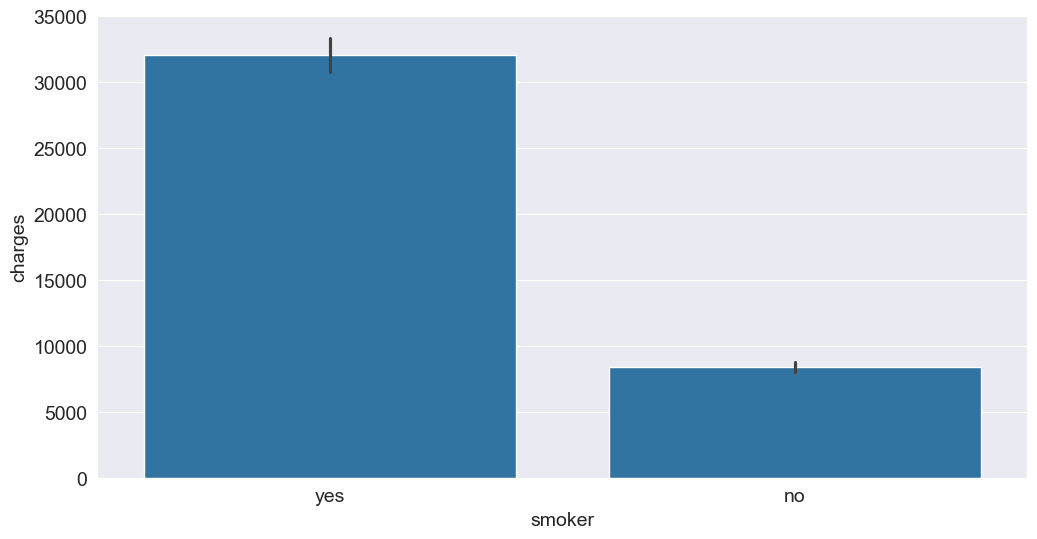

In [72]:
sns.barplot(data=medical_df , x = 'smoker' , y='charges' )

In [73]:
smoker_codes = {'no' : 0 , 'yes' :1}
#new Column called as `smoker_code`
medical_df['smoker_code'] = medical_df.smoker.map(smoker_codes)

In [74]:
medical_df.charges.corr(medical_df.smoker_code)

0.7872514304984778

In [75]:
medical_df

,age,sex,bmi,children,smoker,region,charges,smoker_code
0,19,female,27.900,0,yes,southwest,16884.92400,1
1,18,male,33.770,1,no,southeast,1725.55230,0
2,28,male,33.000,3,no,southeast,4449.46200,0
3,33,male,22.705,0,no,northwest,21984.47061,0
4,32,male,28.880,0,no,northwest,3866.85520,0
...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,0
1334,18,female,31.920,0,no,northeast,2205.98080,0
1335,18,female,36.850,0,no,southeast,1629.83350,0
1336,21,female,25.800,0,no,southwest,2007.94500,0


We can now use the `smoker_df` column for linear regression.

$charges = w_1 \times age + w_2 \times bmi + w_3 \times charges + w_4 \times smoker + b$

In [76]:
inputs , targets = medical_df[['age' , 'bmi' , 'children' , 'smoker_code']], medical_df['charges']

model = LinearRegression().fit(inputs , targets)

predictions = model.predict(inputs)

loss = rmse(targets , predictions)

print("loss :" , loss)

loss : 6056.439217188081


The loss reduces from `11355` to `6056`, almost by 50%! This is an important lesson: never ignore categorical data.


Let's try adding the "sex" column as well.

$charges = w_1 \times age + w_2 \times bmi + w_3 \times charges + w_4 \times smoker + w_5 \times sex + b$

<AxesSubplot:xlabel='sex', ylabel='charges'>

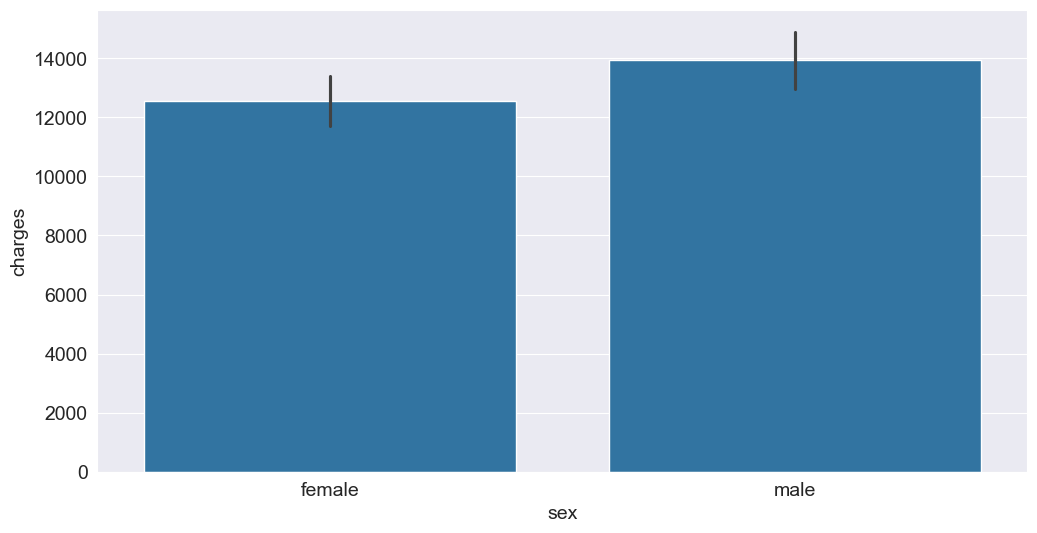

In [77]:
sns.barplot(data=medical_df , x='sex' , y= 'charges')

In [78]:
sex_codes = {'female' : 0 , 'male':  1 }

medical_df['sex_code'] = medical_df.sex.map(sex_codes)
medical_df.charges.corr(medical_df.sex_code)

0.05729206220202533

In [79]:
inputs , targets = medical_df[['age' , 'bmi' , 'children' , 'smoker_code' , 'sex_code']],medical_df['charges']

model = LinearRegression().fit(inputs , targets)

predictions = model.predict(inputs)

loss = rmse(targets , predictions)

print("loss" , loss)

loss 6056.100708754546


As you might expect, this does have a significant impact on the loss.


### One-hot Encoding

The "region" column contains 4 values, so we'll need to use hot encoding and create a new column for each region.

![](https://i.imgur.com/n8GuiOO.png)

<AxesSubplot:xlabel='region', ylabel='charges'>

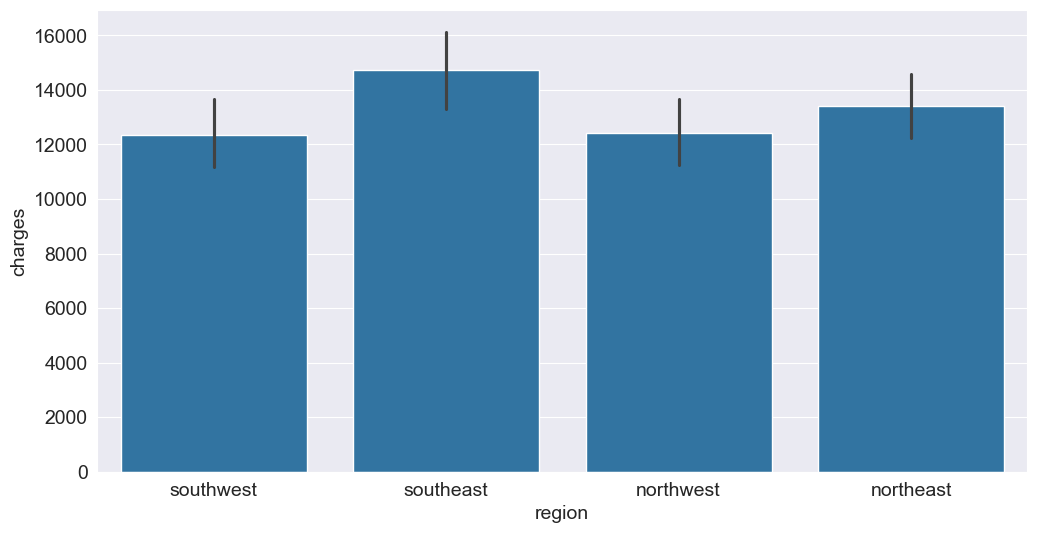

In [80]:
sns.barplot(data=medical_df , x='region' , y='charges')

In [81]:
from sklearn import preprocessing
enc = preprocessing.OneHotEncoder()
enc.fit(medical_df[['region']])
enc.categories_

[array(['northeast', 'northwest', 'southeast', 'southwest'], dtype=object)]

In [83]:
One_hot = enc.transform(medical_df[['region']]).toarray()
One_hot

array([[0., 0., 0., 1.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       ...,
       [0., 0., 1., 0.],
       [0., 0., 0., 1.],
       [0., 1., 0., 0.]])

In [84]:
medical_df[['northeast' , 'northwest' , 'southeast' , 'southwest']] = One_hot


In [85]:
medical_df

,age,sex,bmi,children,smoker,region,charges,smoker_code,sex_code,northeast,northwest,southeast,southwest
0,19,female,27.900,0,yes,southwest,16884.92400,1,0,0.0,0.0,0.0,1.0
1,18,male,33.770,1,no,southeast,1725.55230,0,1,0.0,0.0,1.0,0.0
2,28,male,33.000,3,no,southeast,4449.46200,0,1,0.0,0.0,1.0,0.0
3,33,male,22.705,0,no,northwest,21984.47061,0,1,0.0,1.0,0.0,0.0
4,32,male,28.880,0,no,northwest,3866.85520,0,1,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,0,1,0.0,1.0,0.0,0.0
1334,18,female,31.920,0,no,northeast,2205.98080,0,0,1.0,0.0,0.0,0.0
1335,18,female,36.850,0,no,southeast,1629.83350,0,0,0.0,0.0,1.0,0.0
1336,21,female,25.800,0,no,southwest,2007.94500,0,0,0.0,0.0,0.0,1.0


Let's include the region columns into our linear regression model.

$charges = w_1 \times age + w_2 \times bmi + w_3 \times charges + w_4 \times smoker + w_5 \times sex + w_6 \times region + b$

In [88]:
input_cols = ['age', 'bmi', 'children', 'smoker_code', 'sex_code', 'northeast', 'northwest', 'southeast', 'southwest']
inputs , targets = medical_df[input_cols] , medical_df['charges']

model = LinearRegression().fit(inputs,targets)
predictions = model.predict(inputs)

loss = rmse (targets , predictions)
print('Loss: ' , loss)

Loss:  6041.6796511744515


Once again, this leads to a fairly small reduction to no  loss. 

> **EXERCISE**: Are two separate linear regression models, one for smokers and one of non-smokers, better than a single linear regression model? Why or why not? Try it out and see if you can justify your answer with data.

In [87]:
inputs = medical_df[['age', 'bmi', 'children']]
targets = medical_df['charges']

model = LinearRegression().fit(inputs, targets)

predictions = model.predict(inputs)

loss = rmse(targets, predictions)

print("Single model RMSE:", loss)

Single model RMSE: 11355.317901125973


In [89]:
smokers_df = medical_df[medical_df.smoker_code == 1]
non_smokers_df = medical_df[medical_df.smoker_code == 0]

TRain the model seperate for smokers

In [90]:
smoker_inputs = smokers_df[['age', 'bmi', 'children']]
smoker_targets = smokers_df['charges']

smoker_model = LinearRegression().fit(smoker_inputs, smoker_targets)

smoker_predictions = smoker_model.predict(smoker_inputs)

smoker_loss = rmse(smoker_targets, smoker_predictions)

print("Smoker model RMSE:", smoker_loss)

Smoker model RMSE: 5718.202480524154


also for Non Smokers

In [91]:
non_smoker_inputs = non_smokers_df[['age', 'bmi', 'children']]
non_smoker_targets = non_smokers_df['charges']

non_smoker_model = LinearRegression().fit(
    non_smoker_inputs,
    non_smoker_targets
)

non_smoker_predictions = non_smoker_model.predict(non_smoker_inputs)

non_smoker_loss = rmse(
    non_smoker_targets,
    non_smoker_predictions
)

print("Non-smoker model RMSE:", non_smoker_loss)

Non-smoker model RMSE: 4608.470405038246


In [92]:
combined_predictions = np.empty(len(medical_df))

combined_predictions[medical_df.smoker_code == 1] = smoker_predictions
combined_predictions[medical_df.smoker_code == 0] = non_smoker_predictions

separate_models_loss = rmse(
    medical_df['charges'].to_numpy(),
    combined_predictions
)

print("Single model RMSE:", loss)
print("Separate models RMSE:", separate_models_loss)

Single model RMSE: 6041.6796511744515
Separate models RMSE: 4856.416670731963


#### Conclusion : 
- The two separate linear regression models perform better than a single linear regression model. The single model has an RMSE of 6041.68, while the separate smoker and non-smoker models have a combined RMSE of 4856.42. This represents approximately a 19.6% reduction in RMSE, indicating that separate models are better able to capture the different relationships between age, BMI, children, and medical charges for smokers and non-smokers.

## Model Improvements

Let's discuss and apply some more improvements to our model.

### Feature Scaling

Recall that due to regulatory requirements, we also need to explain the rationale behind the predictions our model. 

$charges = w_1 \times age + w_2 \times bmi + w_3 \times charges + w_4 \times smoker + w_5 \times sex + w_6 \times northeast + w_7 \times northwest+ w_8 \times southeast+ w_9 \times southwest  + b$

To compare the importance of each feature in the model, our first instinct might be to compare their weights. 

In [93]:
input_cols = ['age', 'bmi', 'children', 'smoker_code', 'sex_code', 'northeast', 'northwest', 'southeast', 'southwest']
inputs , targets = medical_df[input_cols] , medical_df['charges']

model = LinearRegression().fit(inputs,targets)
predictions = model.predict(inputs)

loss = rmse (targets , predictions)
print('Loss: ' , loss)

Loss:  6041.6796511744515


In [94]:
model.coef_

array([  256.85635254,   339.19345361,   475.50054515, 23848.53454191,
        -131.3143594 ,   587.00923503,   234.0453356 ,  -448.01281436,
        -373.04175627])

In [95]:
model.intercept_

-12525.54781119545

In [96]:
weights_df = pd.DataFrame({
    'feature' : np.append(input_cols ,1 ),
    'weights' : np.append(model.coef_ , model.intercept_)
})
weights_df

,feature,weights
0,age,256.856353
1,bmi,339.193454
2,children,475.500545
3,smoker_code,23848.534542
4,sex_code,-131.314359
5,northeast,587.009235
6,northwest,234.045336
7,southeast,-448.012814
8,southwest,-373.041756
9,1,-12525.547811


While it seems like BMI and the "northeast" have a higher weight than age, keep in mind that the range of values for BMI is limited (15 to 40) and the "northeast" column only takes the values 0 and 1.

Because different columns have different ranges, we run into two issues:

1. We can't compare the weights of different column to identify which features are important
2. A column with a larger range of inputs may disproportionately affect the loss and dominate the optimization process.

For this reason, it's common practice to scale (or standardize) the values in numeric column by subtracting the mean and dividing by the standard deviation.

![](https://i.imgur.com/dT5fLFI.png)

We can apply scaling using the StandardScaler class from `scikit-learn`.

In [98]:
medical_df

,age,sex,bmi,children,smoker,region,charges,smoker_code,sex_code,northeast,northwest,southeast,southwest
0,19,female,27.900,0,yes,southwest,16884.92400,1,0,0.0,0.0,0.0,1.0
1,18,male,33.770,1,no,southeast,1725.55230,0,1,0.0,0.0,1.0,0.0
2,28,male,33.000,3,no,southeast,4449.46200,0,1,0.0,0.0,1.0,0.0
3,33,male,22.705,0,no,northwest,21984.47061,0,1,0.0,1.0,0.0,0.0
4,32,male,28.880,0,no,northwest,3866.85520,0,1,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,0,1,0.0,1.0,0.0,0.0
1334,18,female,31.920,0,no,northeast,2205.98080,0,0,1.0,0.0,0.0,0.0
1335,18,female,36.850,0,no,southeast,1629.83350,0,0,0.0,0.0,1.0,0.0
1336,21,female,25.800,0,no,southwest,2007.94500,0,0,0.0,0.0,0.0,1.0


In [100]:
from sklearn.preprocessing import StandardScaler


In [103]:
numeric_cols = ['age' , 'bmi' , 'children']
scaler = StandardScaler().fit(medical_df[numeric_cols])

In [104]:
scaler.mean_

array([39.20702541, 30.66339686,  1.09491779])

In [105]:
scaler.var_

array([197.25385199,  37.16008997,   1.45212664])

We can now scale data as follows:

In [106]:
scaled_inputs = scaler.transform(medical_df[numeric_cols])
scaled_inputs

array([[-1.43876426, -0.45332   , -0.90861367],
       [-1.50996545,  0.5096211 , -0.07876719],
       [-0.79795355,  0.38330685,  1.58092576],
       ...,
       [-1.50996545,  1.0148781 , -0.90861367],
       [-1.29636188, -0.79781341, -0.90861367],
       [ 1.55168573, -0.26138796, -0.90861367]])

These can now we combined with the categorical data

In [108]:
cat_cols = ['smoker_code' , 'sex_code' , 'northeast','northwest' , 'southeast' ,'southwest' ]
categorical_data = medical_df[cat_cols].values

In [110]:
inputs = np.concatenate((scaled_inputs , categorical_data), axis = 1)
targets = medical_df.charges


model = LinearRegression().fit(inputs , targets)
predictions = model.predict(inputs)

loss = rmse(targets , predictions)

print("loss :" , loss)

loss : 6041.679651174452


We can now compare the weights in the formula:

$charges = w_1 \times age + w_2 \times bmi + w_3 \times charges + w_4 \times smoker + w_5 \times sex + w_6 \times region + b$

In [111]:
weights_df = pd.DataFrame({
    'feature' : np.append(numeric_cols + cat_cols , 1),
    'weight' : np.append(model.coef_ , model.intercept_)
})
weights_df.sort_values('weight' , ascending = False)


,feature,weight
3,smoker_code,23848.534542
9,1,8466.483215
0,age,3607.472736
1,bmi,2067.691966
5,northeast,587.009235
2,children,572.998210
6,northwest,234.045336
4,sex_code,-131.314359
8,southwest,-373.041756
7,southeast,-448.012814


As you can see now, the most important feature are:

1. Smoker
2. Age
3. BMI

### Creating a Test Set

Models like the one we've created in this tutorial are designed to be used in the real world. It's common practice to set aside a small fraction of the data (e.g. 10%) just for testing and reporting the results of the model.

In [112]:
from sklearn.model_selection import train_test_split

In [114]:
inputs_train , inputs_test , targets_train , targets_test = train_test_split(inputs , targets , test_size = 0.1)

In [115]:
model = LinearRegression().fit(inputs_train , targets_train)

prediction_test = model.predict(inputs_test)

loss = rmse(targets_test , prediction_test)

print("test loss : " , loss)

test loss :  7004.279444979641


In [116]:
# Generate predictions
predictions_train = model.predict(inputs_train)

# Compute loss to evalute the model
loss = rmse(targets_train, predictions_train)
print('Training Loss:', loss)

Training Loss: 5927.487634704745


Can you explain why the training loss is lower than the test loss? We'll discuss this in a lot more detail in future tutorials.
### How to Approach a Machine Learning Problem

Here's a strategy you can apply to approach any machine learning problem:

1. Explore the data and find correlations between inputs and targets
2. Pick the right model, loss functions and optimizer for the problem at hand
3. Scale numeric variables and one-hot encode categorical data
4. Set aside a test set (using a fraction of the training set)
5. Train the model
6. Make predictions on the test set and compute the loss

We'll apply this process to several problems in future tutorials.

### Summary and Further Reading
We've covered the following topics in this tutorial:

- A typical problem statement for machine learning
- Downloading and exploring a dataset for machine learning
- Linear regression with one variable using Scikit-learn
- Linear regression with multiple variables
- Using categorical features for machine learning
- Regression coefficients and feature importance
- Creating a training and test set for reporting results